# import

In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import cv2 as cv
from pathlib import Path 
import seaborn as sns
import matplotlib.pyplot as plt
from StatTools.generators.ndfnoise_generator import ndfnoise
from tqdm import tqdm
import plotly.express as px
import os
import warnings 
import gc

# def

In [ ]:
def calc_soi(canvas, frame_shape, high_frame_threshold, low_frame_threshold, df, thickness):

    canvas_threshold = np.zeros(frame_shape, dtype=np.uint16)
    tracks2draw = df.loc[(df['frame']<high_frame_threshold)&
                              (df['frame']>=low_frame_threshold),
                              'track_id'].unique()
    l2_len = 0
    for tr in tracks2draw:
        # get track points
        pts = df.loc[(df['frame']<high_frame_threshold)&
                          (df['frame']>=low_frame_threshold)&
                          (df['track_id']==tr),
                          ['x', 'y']].to_numpy(dtype=np.int32)
        # calc track l2 length
        increments = np.diff(pts, axis=0)
        l2_len += np.linalg.norm(increments, axis=1).sum()

        # draw track
        buffer = np.zeros(frame_shape, dtype=np.uint8)
        cv.polylines(
            buffer,
            [pts],
            isClosed=False,
            color=1,
            thickness=thickness
        )
        
        canvas_threshold += buffer
        
    canvas += canvas_threshold
    union_mask = canvas > 0 # маска покрытия треками
    intersection_mask = canvas > 1 # маска покрытия хотябы 2-мя треками
    soi_area = intersection_mask.sum() / union_mask.sum()

    intersection_count = canvas - union_mask
    soi_counts = intersection_count.sum() / canvas.sum()

    return canvas, l2_len, soi_area, soi_counts

# pyeensis

In [ ]:
frame_shape = (720, 1280)
thickness = 5
start_frame = 30
dir_path = Path(fr'../data/knn_kalman/pyeensis')
files = list(dir_path.glob("*.csv"))
pbar = tqdm(files)
result = []
for file_path in pbar:
    
    pbar.set_description(f"Processing {file_path.name}")
    try:
        df_test = pd.read_csv(file_path, dtype={'frame':np.uint16, 'track_id':np.uint16, 'x':np.float16, 'y':np.float16}, usecols=['frame', 'track_id', 'x', 'y'])
        df_test = df_test[(df_test['x']>=0)&(df_test['y']>=0)].reset_index(drop=True)
        df_test = df_test.round().astype({'x': np.uint16, 'y': np.uint16})

        frame_thresholds =np.exp(np.arange(np.log(start_frame+10), np.log(df_test.frame.max()), 0.2)).astype(np.uint16)

        canvas = np.zeros(frame_shape, dtype=np.uint16)
        low_thr = start_frame
        for high_thr in frame_thresholds:
            canvas, l2_len, soi_area, soi_counts = calc_soi(canvas,
                                                            frame_shape,
                                                            high_thr,
                                                            low_thr, 
                                                            df_test, 
                                                            thickness=thickness)

            
            low_thr = high_thr

            result.append({
                'species': 'P.yeensis',
                'name': f'{file_path.name}',
                'frame_threshold': high_thr,
                'total_l2_path': l2_len,
                'soi_area': soi_area,
                'soi_counts': soi_counts,
            })
    except Exception as e:
        warnings.warn(f"Ошибка в {file_path.name}: {e}")
        continue

df_res = pd.DataFrame(result)
df_res.to_pickle(f'../data/artifacts/knn_kalman_pyeensis_soi_fix.pkl')

# frufa

In [ ]:
frame_shape = (480, 848)
thickness = 5
start_frame = 30
dir_path = Path(fr'../data/knn_kalman/frufa')
files = list(dir_path.glob("*.csv"))
pbar = tqdm(files)
result = []
for file_path in pbar:
    
    pbar.set_description(f"Processing {file_path.name}")
    try:
        df_test = pd.read_csv(file_path, dtype={'frame':np.uint16, 'track_id':np.uint16, 'x':np.float16, 'y':np.float16}, usecols=['frame', 'track_id', 'x', 'y'])
        df_test = df_test[(df_test['x']>=0)&(df_test['y']>=0)].reset_index(drop=True)
        df_test = df_test.round().astype({'x': np.uint16, 'y': np.uint16})

        frame_thresholds =np.exp(np.arange(np.log(start_frame+10), np.log(df_test.frame.max()), 0.2)).astype(np.uint16)

        canvas = np.zeros(frame_shape, dtype=np.uint16)
        low_thr = start_frame
        for high_thr in frame_thresholds:
            canvas, l2_len, soi_area, soi_counts = calc_soi(canvas,
                                                            frame_shape,
                                                            high_thr,
                                                            low_thr, 
                                                            df_test, 
                                                            thickness=thickness)

            
            low_thr = high_thr

            result.append({
                'species': 'F.rufa',
                'name': f'{file_path.name}',
                'frame_threshold': high_thr,
                'total_l2_path': l2_len,
                'soi_area': soi_area,
                'soi_counts': soi_counts,
            })
    except Exception as e:
        warnings.warn(f"Ошибка в {file_path.name}: {e}")
        continue
    
df_res = pd.DataFrame(result)
df_res.to_pickle(f'../data/artifacts/knn_kalman_frufa_soi_fix.pkl')

Processing S1240025.csv: 100%|██████████| 21/21 [1:34:36<00:00, 270.32s/it]          


# plots

In [27]:
df_frufa_kalman = pd.read_pickle('../data/artifacts/knn_kalman_frufa_soi_fix.pkl')
df_pyeensis_kalman = pd.read_pickle('../data/artifacts/knn_kalman_pyeensis_soi_fix.pkl')
# df_pyeensis_kalman_fixed = pd.read_pickle('../data/artifacts/knn_lk_pyeensis_soi_fix.pkl')
# df_frufa_lk = pd.read_pickle('../data/artifacts/knn_lk_frufa_soi.pkl')
# df_pyeensis_lk = pd.read_pickle('../data/artifacts/knn_lk_pyeensis_soi.pkl')

In [ ]:
# df_lk_old = pd.read_pickle('../data/artifacts/track_length_iou_estimation.pkl')

In [28]:
df_kalman = pd.concat([df_frufa_kalman, df_pyeensis_kalman], axis=0)
# df_lk = pd.concat([df_frufa_lk, df_pyeensis_lk], axis=0)

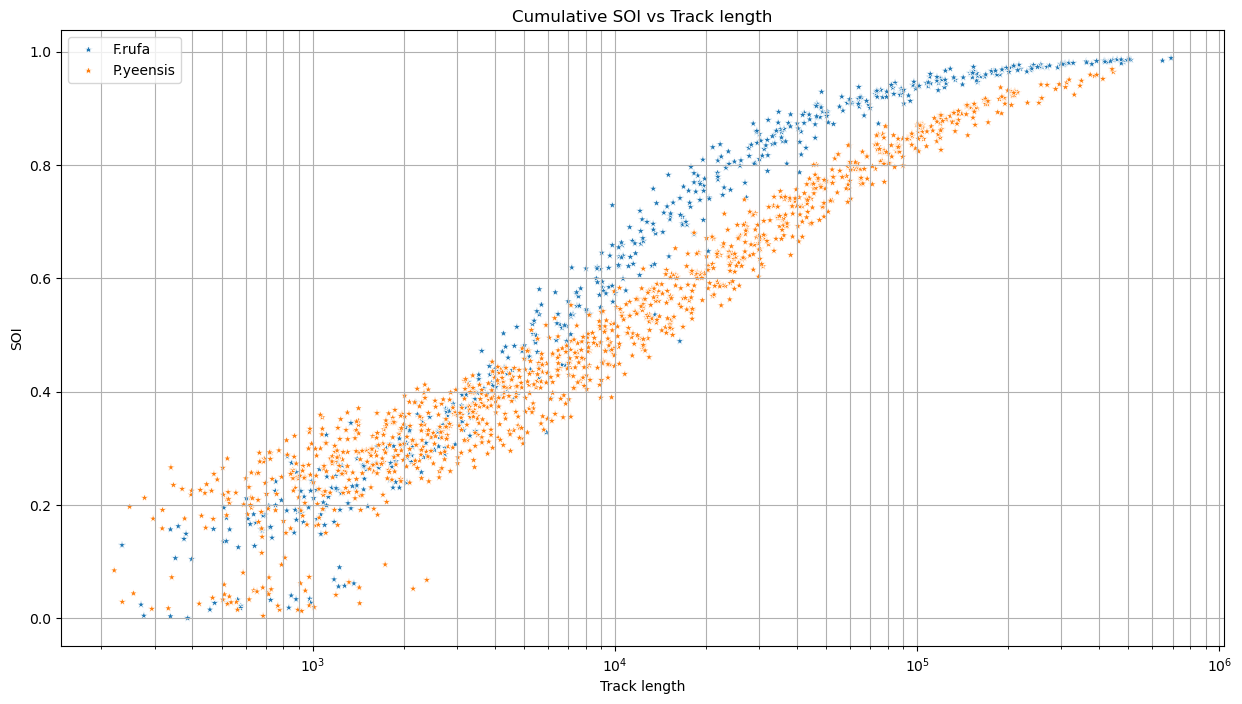

In [30]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df_kalman, x='total_l2_path', y='soi_counts', hue='species', marker='*')
# sns.scatterplot(data=df_pyeensis_kalman_fixed, x='total_l2_path', y='soi_counts', hue='species', marker='+', palette='viridis')
plt.title('Cumulative SOI vs Track length')
plt.xlabel('Track length')
plt.ylabel('SOI')
plt.xscale('log')
plt.legend()
# plt.yscale('log')
plt.grid(which='both')
# plt.savefig('../data/artifacts/cdf_species_with_synth_iou_track_length_seaborn.png')
plt.show()

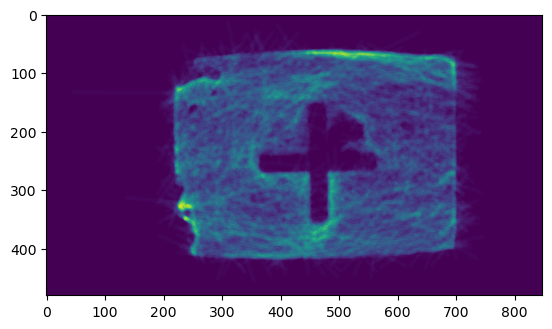

In [32]:
plt.imshow(canvas, cmap='viridis')

In [31]:
import plotly.graph_objects as go

X, Y = np.meshgrid(np.arange(canvas.shape[1]), np.arange(canvas.shape[0]))

fig = go.Figure(data=[go.Surface(x=X, y=Y, z=canvas, colorscale='dense')])

fig.update_layout(
    title='3D P.yeensis trails',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Count',
        xaxis=dict(autorange='reversed')
    ),
    width=900,
    height=700
)

fig.show()